
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [1]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [2]:

# Update this path to your XES file
xes_path = "D:\\TUE Study Material\\Q4\\Process Intelligence in Action\\Assignment\\Process-Analytics-in-Action\\Supermarket_Counter.xes"

log = xes_importer.apply(xes_path)

print(type(log))
print(f"Number of traces: {len(log)}")


d:\TUE Study Material\Q2\Advanced Process Mining\Assignment\Phase3\course-applied-processmining\.venv\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

<class 'pm4py.objects.log.obj.EventLog'>
Number of traces: 18



## 4. Inspecting traces and events

An imported XES log behaves like a **list of traces**.
Each trace behaves like a **list of events**.


In [17]:

# Inspect the first trace
first_trace = log[0]

print(type(first_trace))
print(f"Number of events in first trace: {len(first_trace)}")
print("Trace attributes:")
print(first_trace.attributes)


<class 'pm4py.objects.log.obj.Trace'>
Number of events in first trace: 153860
Trace attributes:
{'concept:name': '0'}


In [18]:
log[0]

{'attributes': {'concept:name': '0'}, 'events': [{'col': '[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,0,0,false),(4,0,0,false),(5,0,0,false),(6,0,0,false),(7,0,0,false),(8,0,0,false),(9,0,0,false),(10,0,0,false),(11,0,0,false),(12,0,0,false),(13,0,0,false),(14,0,0,false),(15,0,0,false),(16,0,0,false),(17,0,0,false)]', 'q': '[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]', 'concept:name': 'Open counter', 'iMI': -1.0, 'd': 4.0, 'mC': 0.0, 'caid': 2.0, 'lifecycle:transition': 'complete', 'mI': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 14, 0, tzinfo=datetime.timezone.utc), 'iMC': -1.0, 'i': nan, 'p': nan, 's': nan, 'pc': nan, 'id': nan, 'items': nan, 'b': nan, 'clid': nan, 'cnt': nan, 'x': nan, 'case:concept:name': '0'}, '..', {'col': '[(0,0,0,true),(1,0,0,false),(2,0,0,true),(3,0,0,false),(4,0,0,false),(5,0,0,true),(6,0,0,false),(7,0,0,true),(8,0,0,true),(9,0,0,false),(10,0,0,true),(11,0,0,false),(12,0,0,false),(13,0,0,false),(14,0,0,false),(15,0,0,false),(16,0,0,false),(17,0,0

In [19]:

# Inspect the first event of the first trace
first_event = first_trace[0]

print(type(first_event))
print(first_event)


<class 'pm4py.objects.log.obj.Event'>
{'col': '[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,0,0,false),(4,0,0,false),(5,0,0,false),(6,0,0,false),(7,0,0,false),(8,0,0,false),(9,0,0,false),(10,0,0,false),(11,0,0,false),(12,0,0,false),(13,0,0,false),(14,0,0,false),(15,0,0,false),(16,0,0,false),(17,0,0,false)]', 'q': '[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]', 'concept:name': 'Open counter', 'iMI': -1.0, 'd': 4.0, 'mC': 0.0, 'caid': 2.0, 'lifecycle:transition': 'complete', 'mI': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 14, 0, tzinfo=datetime.timezone.utc), 'iMC': -1.0, 'i': nan, 'p': nan, 's': nan, 'pc': nan, 'id': nan, 'items': nan, 'b': nan, 'clid': nan, 'cnt': nan, 'x': nan, 'case:concept:name': '0'}



## 5. Common event attributes

Typical event attributes you should always look for:
- `concept:name` – the activity name
- `time:timestamp` – when the event occurred
- `org:resource` – who executed it (if available)

Not all logs contain all attributes.


In [20]:

# Collect all event attribute keys in the log
attribute_keys = set()

for trace in log:
    for event in trace:
        attribute_keys.update(event.keys())

attribute_keys


{'b',
 'caid',
 'case:concept:name',
 'clid',
 'cnt',
 'col',
 'concept:name',
 'd',
 'i',
 'iMC',
 'iMI',
 'id',
 'items',
 'lifecycle:transition',
 'mC',
 'mI',
 'p',
 'pc',
 'q',
 's',
 'time:timestamp',
 'x'}


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [58]:

log_df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

log_df.head(100)


,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"[(0,1,42,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,42.0,2026-01-26 14:12:45.072000+00:00,...,Pin,lItem,1.0,2.0,42.0,False,NaN,NaN,NaN,0
96,"[(0,1,41,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,41.0,2026-01-26 14:12:48.757000+00:00,...,Pin,lItem,1.0,2.0,41.0,False,NaN,NaN,NaN,0
97,"[(0,1,40,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,40.0,2026-01-26 14:12:51.350000+00:00,...,Pin,lItem,1.0,2.0,40.0,False,NaN,NaN,NaN,0
98,"[(0,1,39,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,39.0,2026-01-26 14:12:54.747000+00:00,...,Pin,lItem,1.0,2.0,39.0,False,NaN,NaN,NaN,0



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 7. Basic exploratory analysis


In [22]:

# Number of events
len(log_df)


1234898

In [23]:

# Number of unique cases
log_df['case:concept:name'].nunique()


18

In [24]:

# Most frequent activities
log_df['concept:name'].value_counts().head(10)


concept:name
Scan Item            1127675
Enter Queue            25325
Complete Payment       25325
Start Payment          25325
End price check        14892
Start Price Check      14892
Open counter             732
Close counter            732
Name: count, dtype: int64

In [25]:

# Trace length distribution
trace_lengths = log_df.groupby('case:concept:name').size()
trace_lengths.describe()


count        18.000000
mean      68605.444444
std       34318.496827
min       17569.000000
25%       45690.500000
50%       78302.500000
75%       84607.250000
max      153860.000000
dtype: float64


## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [26]:

# Ensure correct ordering
log_df_sorted = log_df.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_sorted.head()


,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0


## 9. Computing case duration

Case duration is the time between the first and last event of a case (trace).
This is one of the most basic but informative performance indicators.

In [27]:
# Compute case start and end times
case_times = (
    log_df_sorted
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
)

# Compute duration in seconds
case_times['duration_seconds'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds()

case_times.head()

,min,max,duration_seconds
case:concept:name,,,
0,2026-01-26 14:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3398690.954
1,2026-01-26 15:00:00+00:00,2026-03-06 19:06:14.125000+00:00,3384374.125
10,2026-01-26 17:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3387890.954
11,2026-01-26 18:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3384290.954
12,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135


In [28]:
# Compute duration in days
case_times['duration_days'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds() / (24 * 60 * 60)
case_times.head(20)

,min,max,duration_seconds,duration_days
case:concept:name,,,,
0,2026-01-26 14:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3398690.954,39.336701
1,2026-01-26 15:00:00+00:00,2026-03-06 19:06:14.125000+00:00,3384374.125,39.170997
10,2026-01-26 17:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3387890.954,39.211701
11,2026-01-26 18:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3384290.954,39.170034
12,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135,36.170476
13,2026-01-27 19:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3121529.135,36.128809
14,2026-01-27 19:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3121529.135,36.128809
15,2026-01-27 20:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3117929.135,36.087143
16,2026-01-27 20:00:00+00:00,2026-03-03 22:05:54.865000+00:00,3031554.865,35.087441


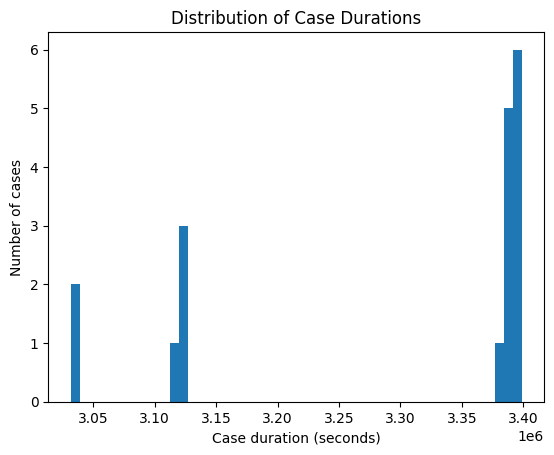

In [29]:
# Plot case duration histogram
import matplotlib.pyplot as plt

plt.hist(case_times['duration_seconds'], bins=50)
plt.xlabel("Case duration (seconds)")
plt.ylabel("Number of cases")
plt.title("Distribution of Case Durations")
plt.show()

## 10. Variants: identifying execution paths

A variant is a unique sequence of activities executed by a case.
Variants are essential for understanding process complexity and deviations.

In [56]:
# Build activity sequences per case
variants = (
    log_df_sorted
    .groupby('case:concept:name')['concept:name']
    .apply(tuple)
)

variants.head()

case:concept:name
0     (Open counter, Enter Queue, Scan Item, Scan It...
1     (Open counter, Enter Queue, Enter Queue, Scan ...
10    (Open counter, Enter Queue, Scan Item, Scan It...
11    (Open counter, Enter Queue, Scan Item, Scan It...
12    (Open counter, Enter Queue, Scan Item, Scan It...
Name: concept:name, dtype: object

In [57]:
# Count variant frequencies
#pd.set_option('display.max_colwidth', None)
variant_counts = variants.value_counts().reset_index()
variant_counts.columns = ['variant', 'frequency']

variant_counts.head(10)


,variant,frequency
0,"(Open counter, Enter Queue, Scan Item, Scan It...",1
1,"(Open counter, Enter Queue, Enter Queue, Scan ...",1
2,"(Open counter, Enter Queue, Scan Item, Scan It...",1
3,"(Open counter, Enter Queue, Scan Item, Scan It...",1
4,"(Open counter, Enter Queue, Scan Item, Scan It...",1
5,"(Open counter, Enter Queue, Scan Item, Scan It...",1
6,"(Open counter, Enter Queue, Scan Item, Scan It...",1
7,"(Open counter, Enter Queue, Scan Item, Scan It...",1
8,"(Open counter, Enter Queue, Scan Item, Scan It...",1
9,"(Open counter, Enter Queue, Scan Item, Scan It...",1


## 11. Activity frequency analysis

Activity frequencies provide a first structural view of the process.

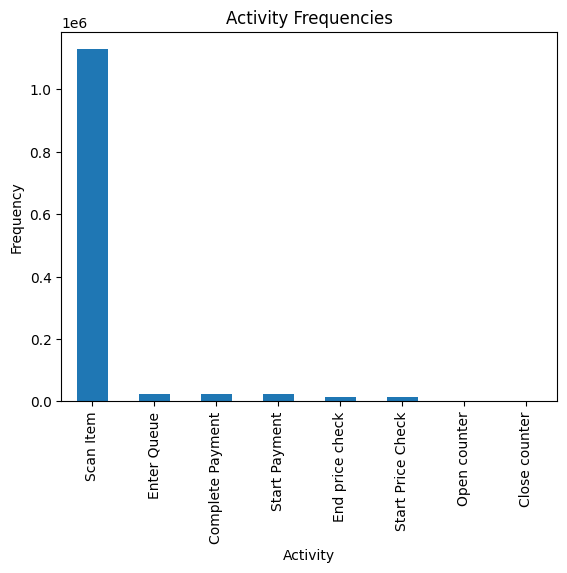

In [18]:
# Bar chart of activity frequencies
activity_counts = log_df['concept:name'].value_counts()

activity_counts.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.title("Activity Frequencies")
plt.show()


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

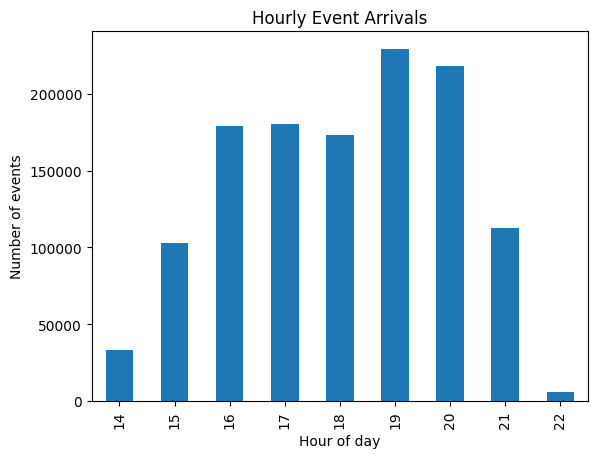

In [19]:
# Hourly arrivals
log_df['hour'] = log_df['time:timestamp'].dt.hour

hourly_arrivals = log_df.groupby('hour').size()

hourly_arrivals.plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Hourly Event Arrivals")
plt.show()

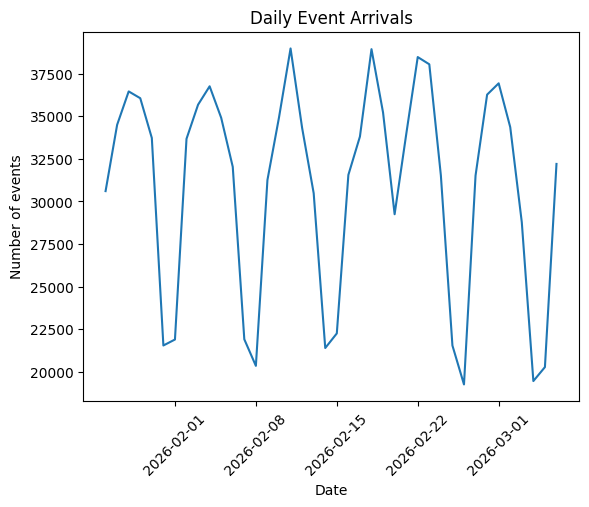

In [20]:
# Daily arrivals
log_df['date'] = log_df['time:timestamp'].dt.date

daily_arrivals = log_df.groupby('date').size()

daily_arrivals.plot()
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Daily Event Arrivals")
plt.show()


## 13. Dotted chart (process timeline visualization)

A dotted chart visualizes:

- x-axis → time
- y-axis → cases
- dots → events, colored by activity

This reveals concurrency, batching, and bottlenecks.

In [14]:
import seaborn as sns

In [68]:

start = pd.Timestamp("2026-01-26 14:13:30", tz="UTC")
end   = pd.Timestamp("2026-01-26 14:14:00", tz="UTC")

log_df_day = log_df[
    (log_df['time:timestamp'] >= start) &
    (log_df['time:timestamp'] < end)
]



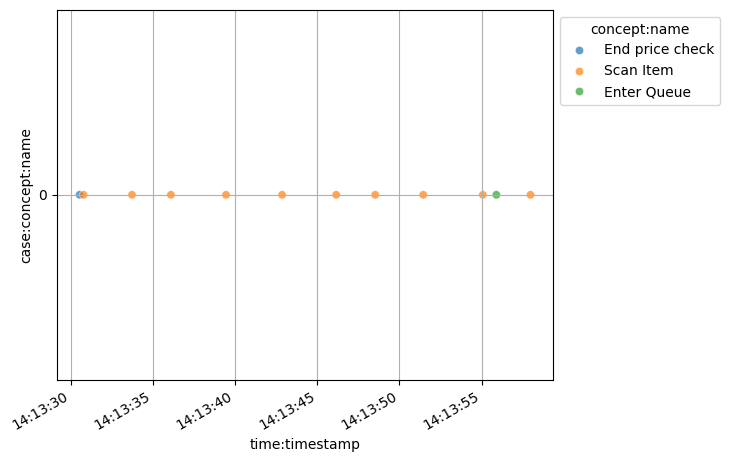

In [69]:
dotted_chart = sns.scatterplot(log_df_day.sort_values(by="time:timestamp"), x='time:timestamp', y='case:concept:name', hue='concept:name', alpha=.7)
sns.move_legend(dotted_chart, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.grid()
dotted_chart;

## 14. Process discovery with pm4py

**Process discovery** automatically derives a process model from event data.
We start with the **Directly-Follows Graph (DFG)** and discover a **Petri net**.

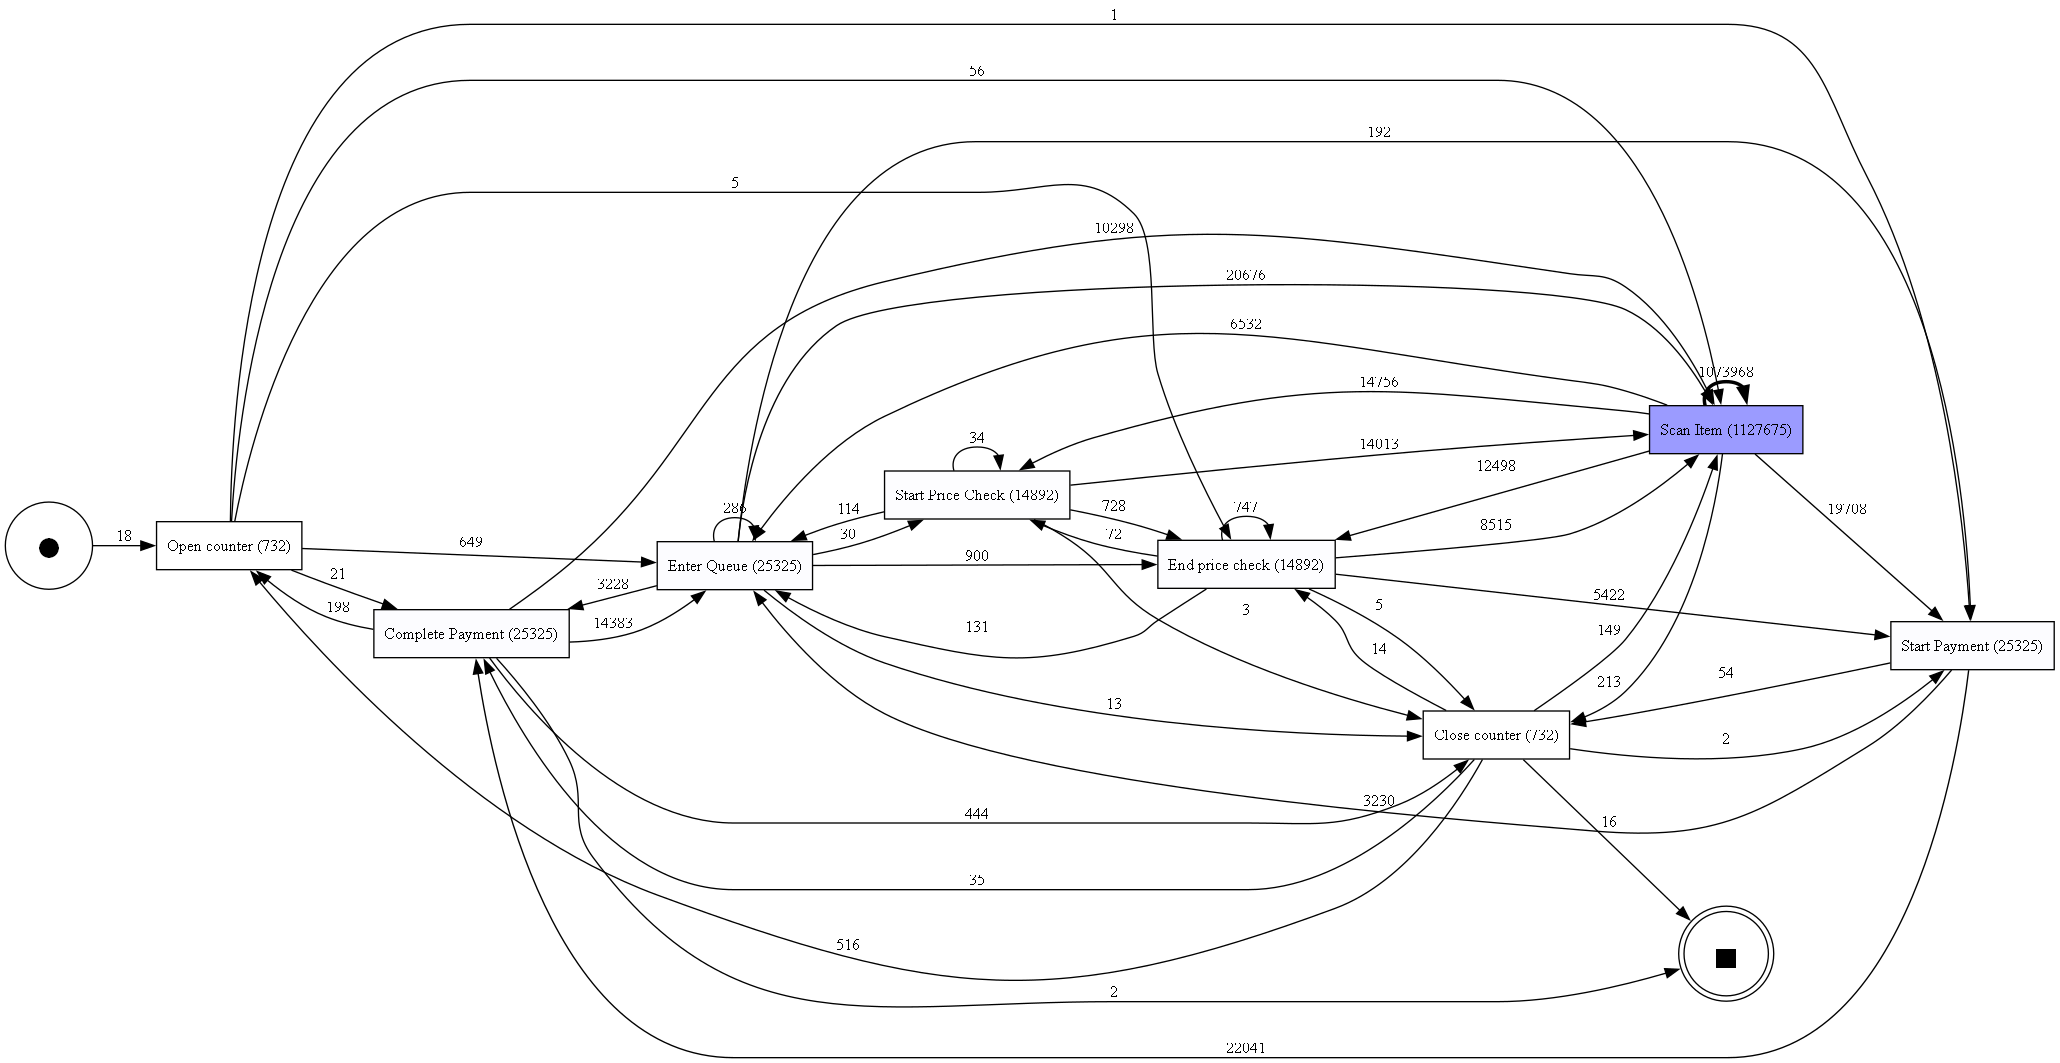

In [24]:
# Discover and visualize DFG
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

pm4py.view_dfg(dfg, start_activities, end_activities)


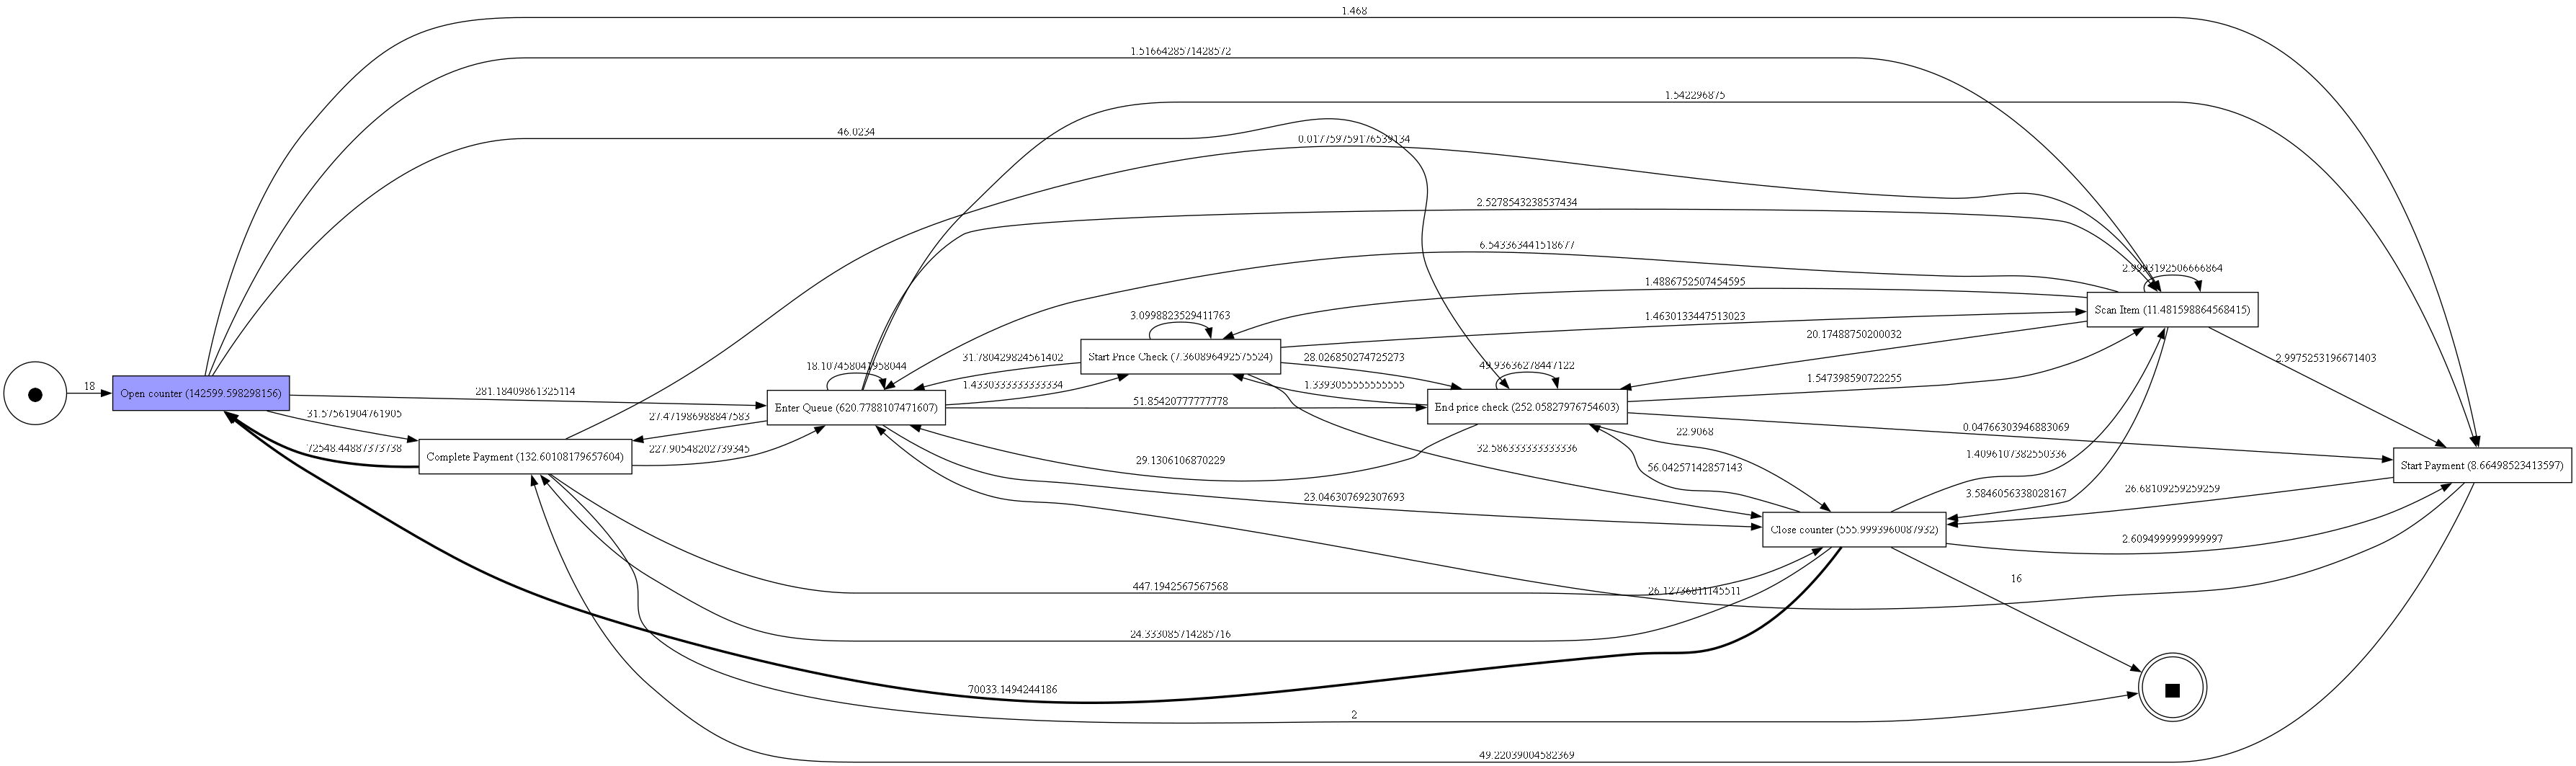

In [25]:
#Performance DFG 
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery # Discover PERFORMANCE DFG (not normal DFG) 
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE) # Visualize it 
pm4py.view_dfg(dfg_perf, start_activities, end_activities)

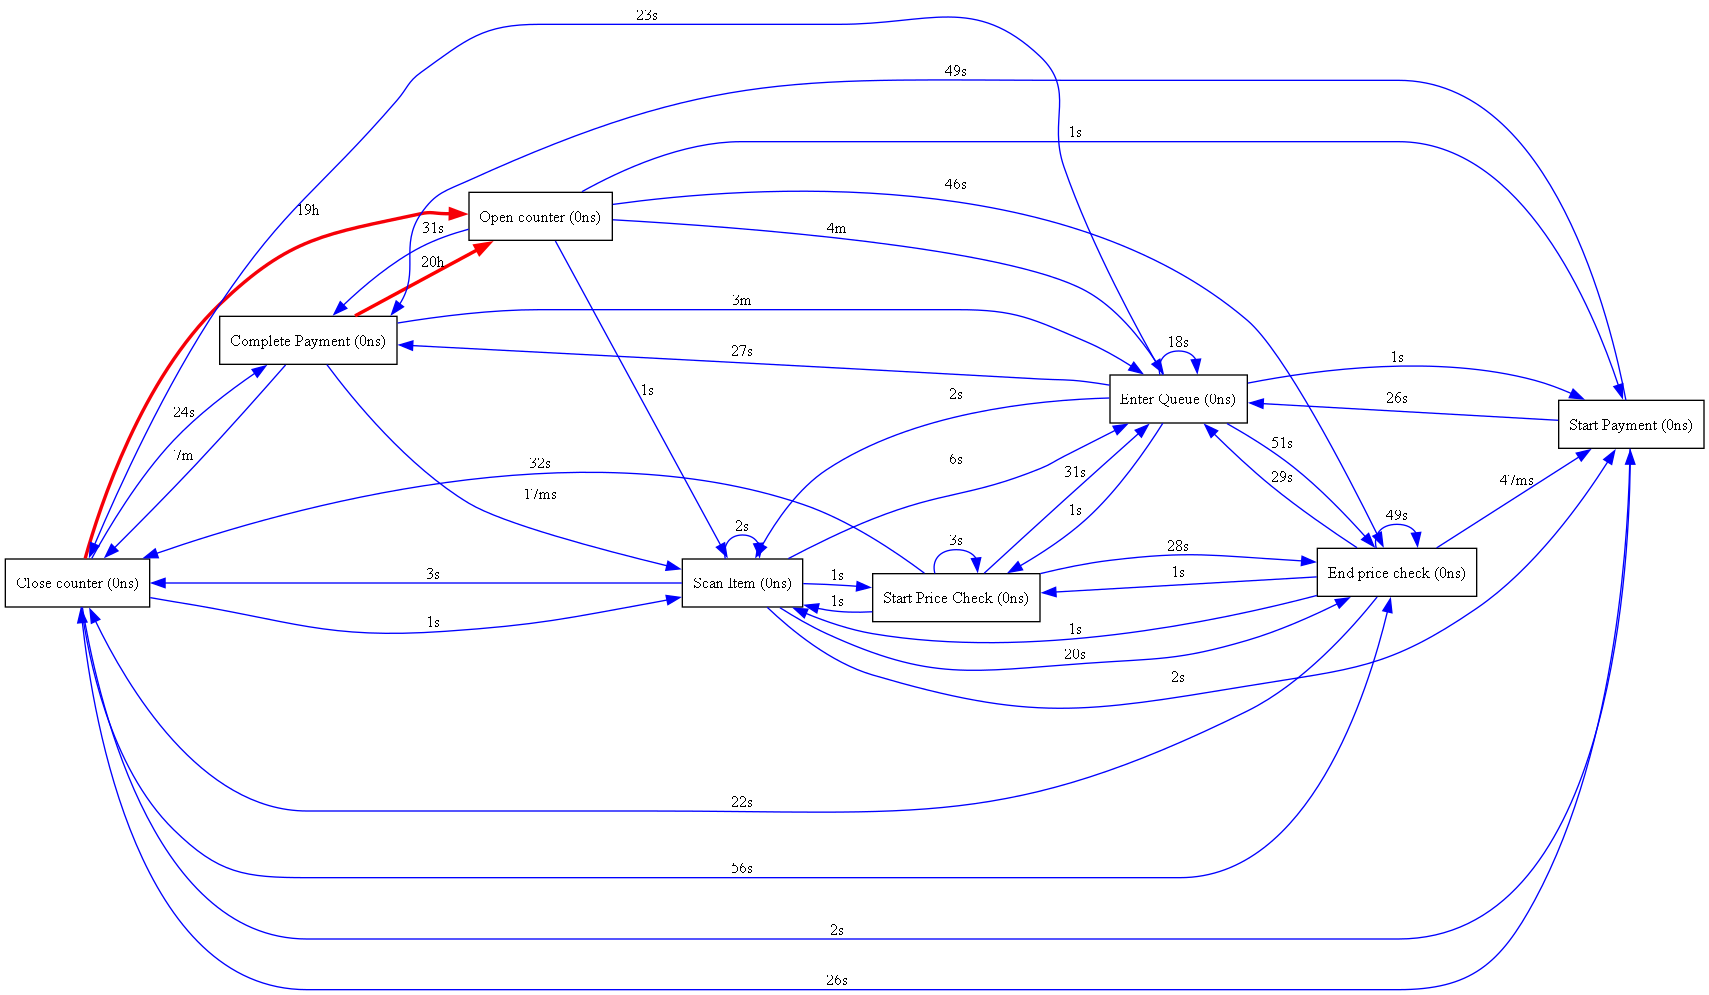

In [26]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

# Discover performance DFG
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE)

# Visualize in HOURS
gviz = dfg_vis.apply(
    dfg_perf,
    log=log,
    variant=dfg_vis.Variants.PERFORMANCE,
    parameters={"time_unit": "minutes"}
)

dfg_vis.view(gviz)

## 9. Handover Gap

In [72]:
import pandas as pd

# -------------------------
# Load handovers
# -------------------------
handover = pd.read_csv(
    "handover.csv",
    parse_dates=['time:timestamp', 'next_time']
)

# -------------------------
# Prepare counter log
# -------------------------
df_counter = log_df_sorted.copy()

# Sort per counter
df_counter = df_counter.sort_values(['case:concept:name', 'time:timestamp'])

# Propagate cashier ID
df_counter['caid_filled'] = df_counter.groupby('case:concept:name')['caid'].ffill()

# -------------------------
# Analysis
# -------------------------
results = []

for _, row in handover.iterrows():
    
    start = row['time:timestamp']
    end = row['next_time']
    
    # -------------------------
    # Identify counter
    # -------------------------
    before_global = df_counter[df_counter['time:timestamp'] < start].tail(1)
    
    if len(before_global) > 0:
        counter_id = before_global.iloc[0]['case:concept:name']
    else:
        counter_id = None
    
    # Filter counter
    if counter_id is not None:
        counter_df = df_counter[df_counter['case:concept:name'] == counter_id]
    else:
        counter_df = pd.DataFrame()
    
    # -------------------------
    # BEFORE handover
    # -------------------------
    before_event = counter_df[counter_df['time:timestamp'] < start].tail(1)
    
    if len(before_event) > 0:
        prev_cashier = before_event.iloc[0]['caid_filled']
        prev_customer = before_event.iloc[0]['id']
    else:
        prev_cashier = None
        prev_customer = None
    
    # -------------------------
    # AFTER handover
    # -------------------------
    after_event = counter_df[counter_df['time:timestamp'] > end].head(1)
    
    if len(after_event) > 0:
        new_cashier = after_event.iloc[0]['caid_filled']
        new_customer = after_event.iloc[0]['id']
    else:
        new_cashier = None
        new_customer = None
    
    # -------------------------
    # DURING handover
    # -------------------------
    counter_slice = counter_df[
        (counter_df['time:timestamp'] >= start) &
        (counter_df['time:timestamp'] <= end)
    ].copy()
    
    # -------------------------
    # Queue + Load calculation
    # -------------------------
    def compute_queue_and_load(row):
        q = row['q']
        
        # Waiting customers
        if isinstance(q, list):
            waiting = len(q)
        else:
            waiting = 0
        
        # Current customer (if id exists)
        current = 1 if pd.notna(row['id']) else 0
        
        # Total load
        total = waiting + current
        
        return pd.Series([waiting, total])
    
    if not counter_slice.empty:
        counter_slice[['waiting_queue', 'total_load']] = counter_slice.apply(
            compute_queue_and_load, axis=1
        )
        
        avg_queue_size = counter_slice['waiting_queue'].mean()
        avg_total_load = counter_slice['total_load'].mean()
    else:
        avg_queue_size = 0
        avg_total_load = 0
    
    # -------------------------
    # Activity metrics
    # -------------------------
    queue_entries = (counter_slice['concept:name'] == 'Enter Queue').sum()
    scans = (counter_slice['concept:name'] == 'Scan Item').sum()
    
    # -------------------------
    # Inefficiency classification
    # -------------------------
    if scans == 0 and queue_entries > 0:
        inefficiency = "Severe"
    elif scans < 3 and queue_entries > 0:
        inefficiency = "Moderate"
    else:
        inefficiency = "Efficient"
    
    # -------------------------
    # Cashier change check
    # -------------------------
    cashier_changed = prev_cashier != new_cashier
    
    # -------------------------
    # Store results
    # -------------------------
    results.append({
        'Start Time': start,
        'End Time': end,
        'Counter': counter_id,
        'Gap (min)': round(row['gap_min'], 2),
        'Prev Cashier': prev_cashier,
        'New Cashier': new_cashier,
        'Prev Customer': prev_customer,
        'New Customer': new_customer,
        'Changed?': cashier_changed,
        'Queue Entries': queue_entries,
        'Scans': scans,
       # 'Avg Queue Size': round(avg_queue_size, 2),
        #'Avg Total Load': round(avg_total_load, 2),
        #'Inefficiency': inefficiency
    })

# -------------------------
# Final dataframe
# -------------------------
handover_check = pd.DataFrame(results)

# -------------------------
# Display nicely
# -------------------------
print(handover_check.to_string(index=False))

                      Start Time                  End Time Counter  Gap (min)  Prev Cashier  New Cashier  Prev Customer  New Customer  Changed?  Queue Entries  Scans
       2026-01-26 19:00:00+00:00 2026-01-26 20:00:00+00:00       9      60.00          18.0          3.0          360.0         491.0      True             14    482
2026-01-27 19:02:13.376000+00:00 2026-01-27 20:00:00+00:00       9      57.78          54.0         54.0         1047.0        1198.0     False             14    657
       2026-01-28 19:00:00+00:00 2026-01-28 20:00:00+00:00       9      60.00          19.0         19.0         1796.0        1932.0     False             22    826
       2026-01-29 19:00:00+00:00 2026-01-29 20:00:00+00:00       9      60.00          56.0          7.0         2578.0        2692.0      True             16    633
2026-01-30 19:00:27.286000+00:00 2026-01-30 20:00:00+00:00       9      59.55          19.0         19.0         3260.0        3400.0     False             15    647
    

In [75]:
comparison = handover_check.groupby('Changed?')['Queue Entries'].mean()

print(comparison)

Changed?
False    16.247059
True     16.200000
Name: Queue Entries, dtype: float64


In [78]:
comparison = handover_check.groupby('Changed?')['Scans'].mean()

print(comparison)

Changed?
False    658.564706
True     662.953846
Name: Scans, dtype: float64


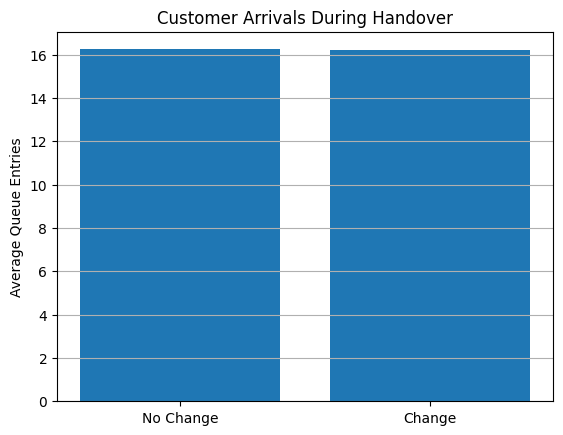

In [76]:
import matplotlib.pyplot as plt

avg_entries = handover_check.groupby('Changed?')['Queue Entries'].mean()

plt.figure()

plt.bar(
    ['No Change', 'Change'],
    avg_entries.values
)

plt.ylabel("Average Queue Entries")
plt.title("Customer Arrivals During Handover")

plt.grid(axis='y')

plt.show()

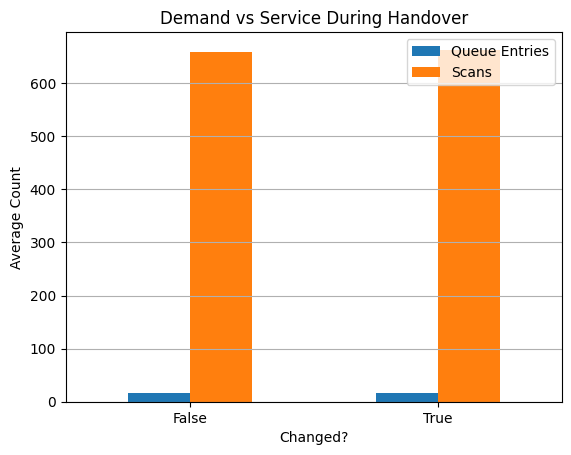

In [77]:
comparison = handover_check.groupby('Changed?')[['Queue Entries','Scans']].mean()

comparison.plot(kind='bar')

plt.title("Demand vs Service During Handover")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

Analysing Gap between Complete Payment and Scanning items

In [53]:

df = log_df_sorted.copy()

# Get next event within same counter
df['next_event'] = df.groupby('case:concept:name')['concept:name'].shift(-1)
df['next_time'] = df.groupby('case:concept:name')['time:timestamp'].shift(-1)
df['next_id'] = df.groupby('case:concept:name')['id'].shift(-1)

# Keep only Complete Payment → Scan Item AND different customer
transitions = df[
    (df['concept:name'] == 'Complete Payment') &
    (df['next_event'] == 'Scan Item') &
    (df['id'] != df['next_id'])   # 🔥 KEY CONDITION
].copy()

# Compute duration
transitions['gap_sec'] = (
    transitions['next_time'] - transitions['time:timestamp']
).dt.total_seconds()

transitions['gap_min'] = transitions['gap_sec'] / 60

# Results
print("Average gap (minutes):", transitions['gap_min'].mean())
print("Median gap (minutes):", transitions['gap_min'].median())
print("Max gap (minutes):", transitions['gap_min'].max())

Average gap (minutes): 0.0002959959862756522
Median gap (minutes): 0.0
Max gap (minutes): 0.059133333333333336


Comparing Pin vs Cash Payments

Payment time comparison:

                    mean    median       max  count
payment_method                                     
Cash            0.443582  0.442692  0.990033   5446
Pin             0.943981  0.944567  1.632317  16595


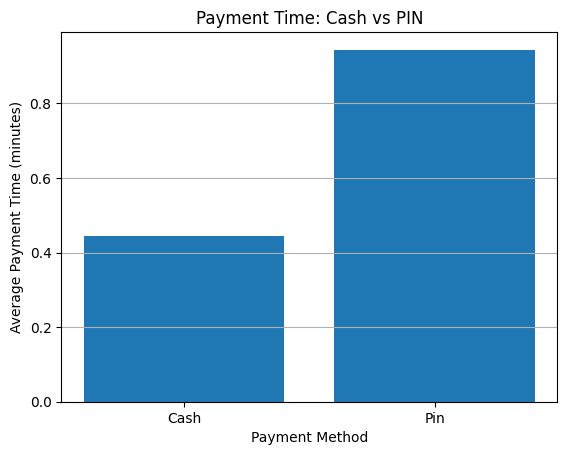

In [79]:
import pandas as pd

df = log_df_sorted.copy()

# Ensure sorted per counter (IMPORTANT)
df = df.sort_values(['case:concept:name', 'time:timestamp'])

# -------------------------
# Get next event and time
# -------------------------
df['next_event'] = df.groupby('case:concept:name')['concept:name'].shift(-1)
df['next_time'] = df.groupby('case:concept:name')['time:timestamp'].shift(-1)

# -------------------------
# Filter Start → Complete Payment transitions
# -------------------------
payments = df[
    (df['concept:name'] == 'Start Payment') &
    (df['next_event'] == 'Complete Payment')
].copy()

# -------------------------
# Compute duration
# -------------------------
payments['payment_time_sec'] = (
    payments['next_time'] - payments['time:timestamp']
).dt.total_seconds()

payments['payment_time_min'] = payments['payment_time_sec'] / 60

# -------------------------
# Keep payment method
# -------------------------
# Assuming column 'p' = payment type (Pin / Cash)
payments['payment_method'] = payments['p']

# -------------------------
# Drop missing payment types
# -------------------------
payments = payments.dropna(subset=['payment_method'])

# -------------------------
# Summary comparison
# -------------------------
summary = payments.groupby('payment_method')['payment_time_min'].agg(
    ['mean', 'median', 'max', 'count']
)

print("Payment time comparison:\n")
print(summary)

# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt

avg_time = payments.groupby('payment_method')['payment_time_min'].mean()

plt.figure()

plt.bar(avg_time.index, avg_time.values)

plt.xlabel("Payment Method")
plt.ylabel("Average Payment Time (minutes)")
plt.title("Payment Time: Cash vs PIN")

plt.grid(axis='y')

plt.show()

In [81]:
print(payments.groupby('payment_method')['payment_time_min'].describe())

                  count      mean       std     min       25%       50%  \
payment_method                                                            
Cash             5446.0  0.443582  0.147200  0.0000  0.345342  0.442692   
Pin             16595.0  0.943981  0.171182  0.3067  0.827650  0.944567   

                     75%       max  
payment_method                      
Cash            0.543875  0.990033  
Pin             1.060208  1.632317  


In [82]:
# Find Start Payment events
start = df[df['concept:name'] == 'Start Payment']

# Find Complete Payment events
end = df[df['concept:name'] == 'Complete Payment']

# Merge by case (customer)
payments = pd.merge(
    start,
    end,
    on='case:concept:name',
    suffixes=('_start', '_end')
)

# Keep only correct order
payments = payments[
    payments['time:timestamp_end'] > payments['time:timestamp_start']
]

# Compute duration
payments['payment_time_min'] = (
    payments['time:timestamp_end'] - payments['time:timestamp_start']
).dt.total_seconds() / 60

##Other

In [45]:
import pm4py
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.log.obj import EventLog
import random

print("Step 1: Getting variants...")
variants = pm4py.get_variants(log)

print("Step 2: Sorting variants...")
variant_counts = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)

print("Step 3: Selecting top variants...")
total_cases = sum(len(v[1]) for v in variant_counts)

selected_variants = []
count = 0

for var, cases in variant_counts:
    selected_variants.append(var)
    count += len(cases)
    if count >= 0.8 * total_cases:
        break

print("Step 4: Filtering log...")
filtered_log = pm4py.filter_variants(log, selected_variants)

sampled = random.sample(list(filtered_log), int(len(filtered_log) * 0.3))
filtered_log=EventLog(sampled)

print("Step 5: Running Inductive Miner... (this is the slow step)")
net, im, fm = inductive_miner.apply(
    filtered_log,
    variant=inductive_miner.Variants.IMf
)

print("Step 6: Visualizing...")
pm4py.view_petri_net(net, im, fm)

print("Done.")

Step 1: Getting variants...
Step 2: Sorting variants...
Step 3: Selecting top variants...
Step 4: Filtering log...
Step 5: Running Inductive Miner... (this is the slow step)


KeyboardInterrupt: 


## Other things to consider when working with XES logs

- Missing or inconsistent timestamps
- Multiple events with identical timestamps
- Multiple lifecycle events (start / complete)
- Very large logs that do not fit in memory
- Assuming every case follows the same path

Always *inspect before modeling*.
